In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import functools
from pathlib import Path
import itertools as itt

import distinctipy
from scipy.stats import pearsonr, spearmanr, kendalltau

from dti import data
from dti.utils import scaffold_split
from dti.constants import SMILES, ASSAY, ACT

sns.set_context("talk")

In [3]:
data_path = Path("..") / "data" / "raw"

In [3]:
df = data.load_kinodata(data_path / "activities-chembl33_v0.5.csv")

In [116]:
df_train, df_test = scaffold_split(df, seed=0, progress=True)
training_mean = df_train[ACT].mean()
predictor = df_train.groupby(ASSAY)[[ACT]].agg("mean")
df_test = df_test.join(
    predictor.rename(columns={ACT: "assay_mean"}), on=ASSAY, how="left"
)

len(df_train), len(df_test)

scaffold:   0%|          | 0/179982 [00:00<?, ?it/s]

(144507, 35475)

In [117]:
df_test.corr(numeric_only=True)

,activities.activity_id,molecule_dictionary.max_phase,activity_value,assays.confidence_score,docs.year,assay_id,compound_id,assay_mean
activities.activity_id,1.000000,-0.056122,0.248380,0.436612,0.911220,0.990884,0.943636,0.312450
molecule_dictionary.max_phase,-0.056122,1.000000,0.068151,-0.144985,0.038309,-0.063686,-0.308611,0.110341
activity_value,0.248380,0.068151,1.000000,0.022012,0.234087,0.245095,0.256879,0.741813
assays.confidence_score,0.436612,-0.144985,0.022012,1.000000,0.408287,0.430487,0.378016,0.058506
docs.year,0.911220,0.038309,0.234087,0.408287,1.000000,0.904922,0.862362,0.285205
assay_id,0.990884,-0.063686,0.245095,0.430487,0.904922,1.000000,0.950272,0.306162
compound_id,0.943636,-0.308611,0.256879,0.378016,0.862362,0.950272,1.000000,0.309393
assay_mean,0.312450,0.110341,0.741813,0.058506,0.285205,0.306162,0.309393,1.000000


R2=0.74
Spearman=0.73
MAE=0.68
Kendall's tau=0.54


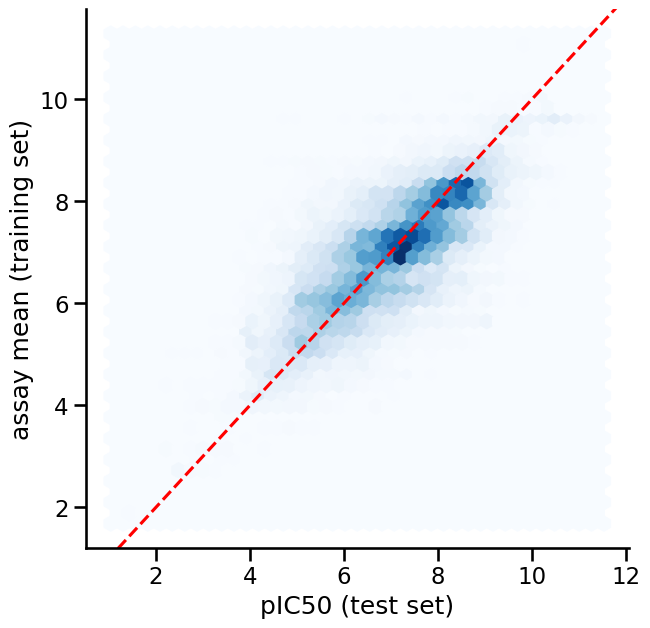

In [149]:
plt.figure(figsize=(7, 7))
xs, ys = df_test["activity_value"].values, df_test["assay_mean"].values
plt.hexbin(xs, ys, gridsize=40, cmap="Blues")
sns.despine()
xl = plt.xlim()
yl = plt.ylim()
plt.plot([0, 15], [0, 15], "r--")
plt.xlim(*xl)
plt.ylim(*yl)
plt.ylabel("assay mean (training set)")
plt.xlabel("pIC50 (test set)")
xs = xs[~np.isnan(ys)]
ys = ys[~np.isnan(ys)]
assert np.all(~np.isnan(xs))
mae = np.abs(xs - ys).mean()
pr = pearsonr(xs, ys).statistic
kt = kendalltau(xs, ys).statistic
sr = spearmanr(xs, ys).statistic
print(f"R2={pr:.2f}\nSpearman={sr:.2f}\nMAE={mae:.2f}\nKendall's tau={kt:.2f}")

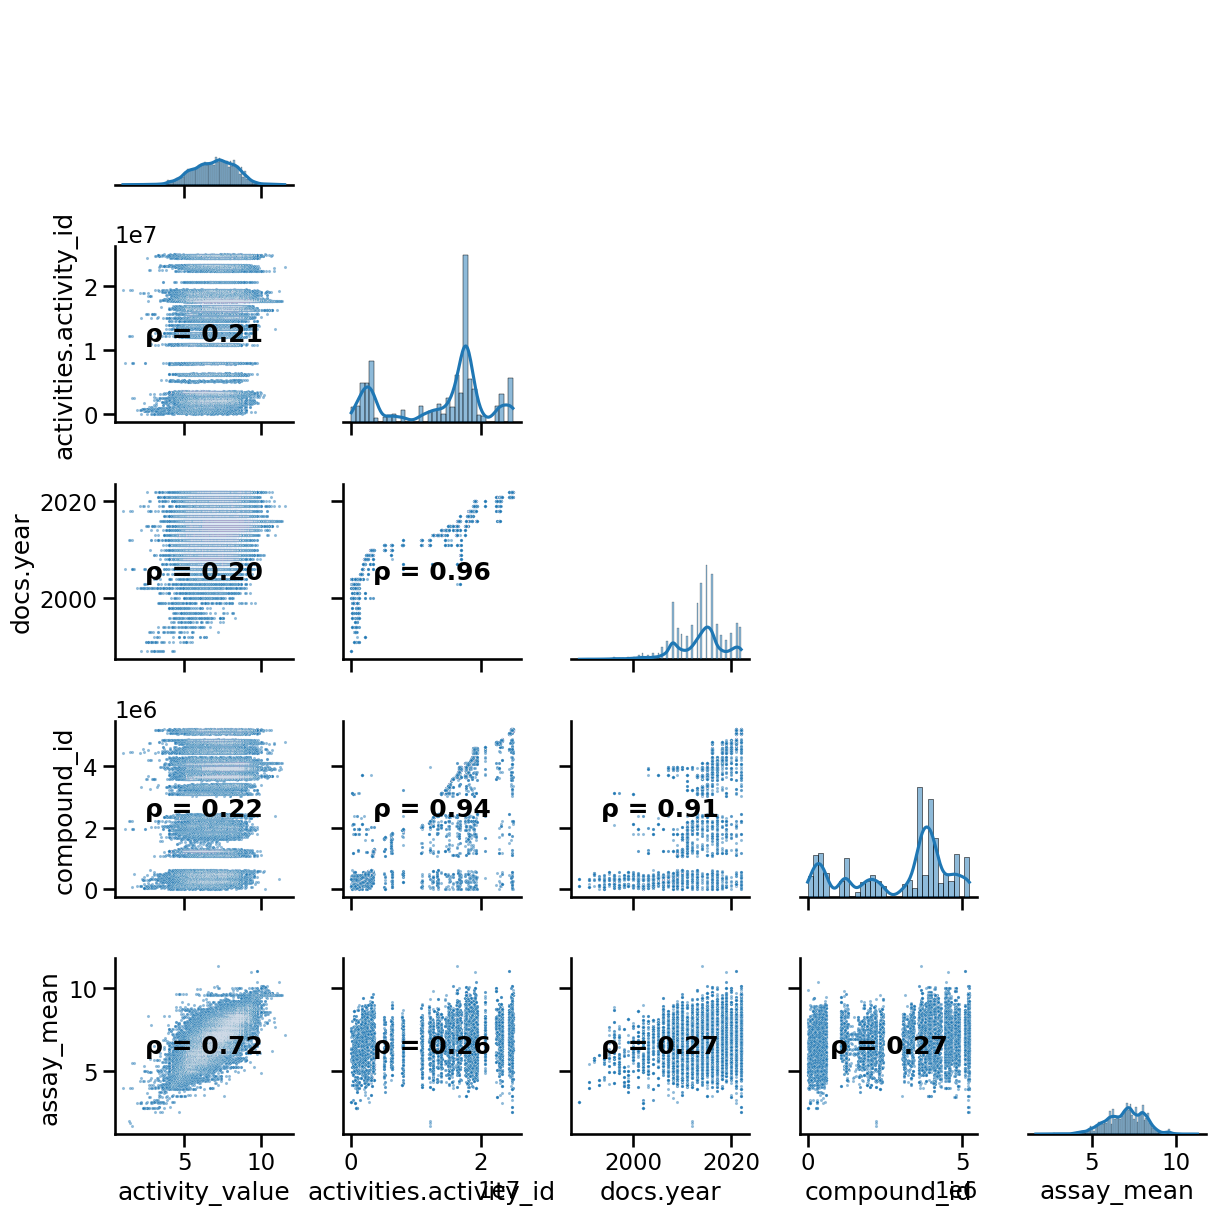

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def corrfunc(x, y, **kws):
    corr = spearmanr(x, y, nan_policy="omit").statistic
    ax = plt.gca()
    ax.annotate(
        f"ρ = {corr:.2f}",
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
    )


cols = [ACT, "activities.activity_id", "docs.year", "compound_id", "assay_mean"]
df_filtered = df_test[df_test["docs.year"] > 1950][cols]

g = sns.PairGrid(df_filtered, corner=True)

g.map_lower(sns.scatterplot, s=5, alpha=0.5)
g.map_offdiag(corrfunc)
g.map_diag(sns.histplot, kde=True)

plt.tight_layout()
plt.savefig("pair.png")